# 🚀 UD-03-800 워드클라우드 실습

워드클라우드 — 형태소 분석 결과를 시각화. Raw text vs Pecab nouns 비교, 키워드 필터링.

> **🖥️ 환경 설정**: 아래 Setup 셀을 먼저 실행하세요.
>- terminal에서 `uv sync` 실행 (uv.lock, pyproject.toml 다운로드 필요)

> **⌨️ 단축키 안내**
> | 단축키 | 동작 |
> |--------|------|
> | `Shift+Enter` | 셀 실행 후 다음 셀 이동 |
> | `a` | 위에 셀 삽입 |
> | `b` | 아래에 셀 삽입 |
> | `dd` | 셀 삭제 |

[→ §310 강의노트](../notes/UD-03-310__wordcloud-pecab.md)

In [1]:
# 📌 §Setup 환경 설정
from wordcloud import WordCloud
from pecab import PeCab
import matplotlib.pyplot as plt

print("Setup 완료")
# 예상 출력: Setup 완료

Setup 완료


In [4]:
# 📌 §310 데이터 준비
# 뉴스 제목 샘플 — 조사, 어미, 보도 관용구 포함
titles = [
    "삼성전자는 이번 3분기 영업이익이 10조원을 돌파한 것으로 밝혀졌다",
    "카카오의 CEO가 사임을 밝히면서 내부 갈등이 심화되고 있다고 전했다",
    "현대차는 올해 전기차 미국 수출이 30% 급증한 것으로 나타났다",
    "네이버와 카카오의 AI 경쟁이 본격화되면서 주가가 급등한 것으로 알려졌다",
    "한국은행은 이번 기준금리를 3.25%로 인하하기로 결정했다고 밝혔다",
    "LG에너지솔루션은 배터리 수주가 20조원을 돌파한 것으로 전했다",
    "SK하이닉스는 HBM3E 양산을 본격화하면서 엔비디아 납품을 확대한다고 밝혔다",
    "정부는 이번 AI 반도체 육성에 5조원을 투자하기로 결정한 것으로 밝혀졌다",
    "삼성전자는 갤럭시 S25를 출시하면서 AI 기능을 대폭 강화했다고 전했다",
    "카카오뱅크는 최근 대출 금리를 인하하면서 시중은행과 경쟁이 심화되고 있다",
    "현대차는 이번 미국 공장 투자를 확대하면서 전기차 생산을 2배로 늘린다고 밝혔다",
    "네이버 클라우드는 정부 과제를 수주하면서 AI 인프라 구축에 나선 것으로 알려졌다",
    "한국 경제 성장률이 2.1%를 기록하면서 소비 회복세가 뚜렷한 것으로 나타났다",
    "삼성 반도체는 미국 공장 가동이 지연되면서 생산에 차질이 있는 것으로 전했다",
    "카카오는 택시와 대리 서비스를 합병하면서 모빌리티 사업을 통합한다고 밝혔다",
    "LG전자는 올해 가전 매출이 사상 최대를 기록하면서 해외 비중이 확대된 것으로 나타났다",
    "정부는 이번 부동산 규제를 완화하면서 대출 한도를 상향했다고 밝혀졌다",
    "SK텔레콤은 AI 비서를 출시하면서 통신사 간 AI 경쟁이 가속되고 있다고 전했다",
    "현대차는 수소차 넥쏘 신모델의 항속거리가 700km를 돌파한 것으로 밝혔다",
    "네이버 웹툰은 글로벌 MAU가 1억을 돌파한 것으로 알려졌다",
    "삼성전자는 이번 4분기 실적이 시장 기대치를 하회한 것으로 나타났다",
    "카카오는 AI 챗봇 서비스를 출시하면서 네이버와 정면 대결에 나선다고 전했다",
    "한국은행은 이번 기준금리를 동결하면서 물가 안정을 우선시한다고 밝혔다",
    "최근 전기차 배터리 화재 사고가 잇따르면서 안전 규제가 강화된 것으로 밝혀졌다",
    "삼성전자는 파운드리 수주를 확대하면서 TSMC를 추격하고 있다고 전했다",
    "정부는 AI 규제 프레임워크를 발표했지만 산업계가 반발하고 있는 것으로 나타났다",
    "현대차와 기아는 올해 글로벌 판매가 700만대를 돌파한 것으로 밝혔다",
    "카카오는 최근 데이터센터 장애로 서비스가 일시 중단됐다고 밝혔다",
    "네이버는 검색 점유율이 하락하면서 AI 검색 대응을 강화하고 있다고 전했다",
    "SK이노베이션은 배터리 분리막을 증설하면서 글로벌 1위를 목표로 하고 있다고 밝혔다",
]
print(f"제목 수: {len(titles)}")


# ✍️ titles 리스트를 " ".join()으로 하나의 문자열(news_title)로 합치고 첫 80자를 출력해보세요
# 코드를 작성해주세요 👇
# 제목을 하나의 문자열로 합치기
news_title = " ".join(titles)
print(news_title[:80])


# 예상 출력: 삼성전자는 이번 3분기 영업이익이 10조원을 돌파한 것으로 밝혀졌다 카카오의 CEO가 ...

제목 수: 30
삼성전자는 이번 3분기 영업이익이 10조원을 돌파한 것으로 밝혀졌다 카카오의 CEO가 사임을 밝히면서 내부 갈등이 심화되고 있다고 전했다 현대차


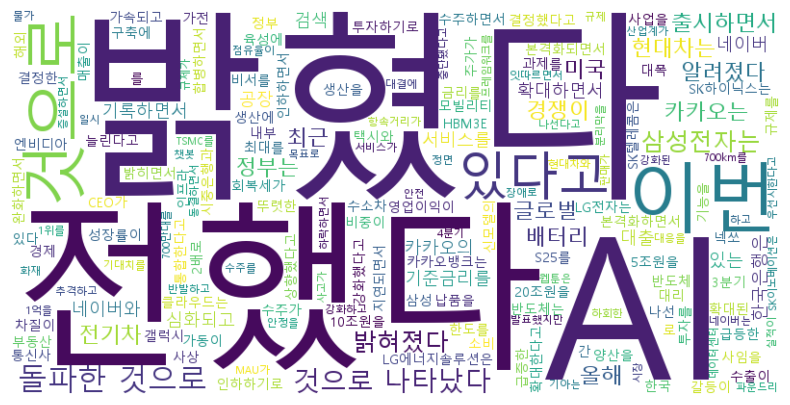

In [3]:
# 📌 §310 Raw WordCloud
# ✍️ news_title을 WordCloud에 넣어 워드클라우드를 생성해보세요
# (힌트: FONT_PATH 설정 → WordCloud(font_path=..., ...).generate(news_title) → plt.imshow)
# 코드를 작성해주세요 👇
from wordcloud import WordCloud
import matplotlib.pyplot as plt

FONT_PATH = r"C:\Windows\Fonts\malgun.ttf"  # Windows: 맑은 고딕

wc = WordCloud(
    font_path=FONT_PATH,
    width=800, height=400,
    background_color="white",
    random_state=42,
).generate(news_title)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# 예상 출력: 워드클라우드 이미지 — "것으로", "밝혔다", "이번" 등 보도 관용구가 크게 나옴

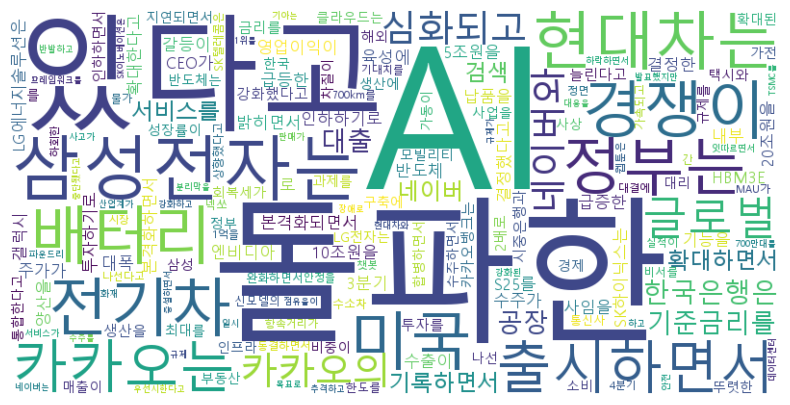

In [5]:
# 📌 §310 Stopwords
# ✍️ stopwords 세트를 만들고 WordCloud의 stopwords 파라미터에 전달해보세요
# (힌트: stopwords={"것으로", "밝혔다", ...} → WordCloud(stopwords=stopwords, ...).generate())
# 코드를 작성해주세요 👇
# 불용어 적용 — 보도 관용구와 시간 표현을 제거
stopwords = {"것으로", "밝혔다", "밝혀졌다", "전했다", "나타났다", "알려졌다",
             "있다", "있는", "됐다", "했다",
             "이번", "올해", "최근", "지난"}

wc_sw = WordCloud(
    font_path=FONT_PATH,
    width=800, height=400,
    stopwords=stopwords,
    background_color="white",
    random_state=42,
).generate(news_title)

plt.figure(figsize=(10, 5))
plt.imshow(wc_sw, interpolation="bilinear")
plt.axis("off")
plt.show()


# 예상 출력: 보도 관용구 제거됨 — 하지만 "삼성전자는", "경쟁이" 등 조사 붙은 토큰은 여전히 큼

c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\pecab\_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]


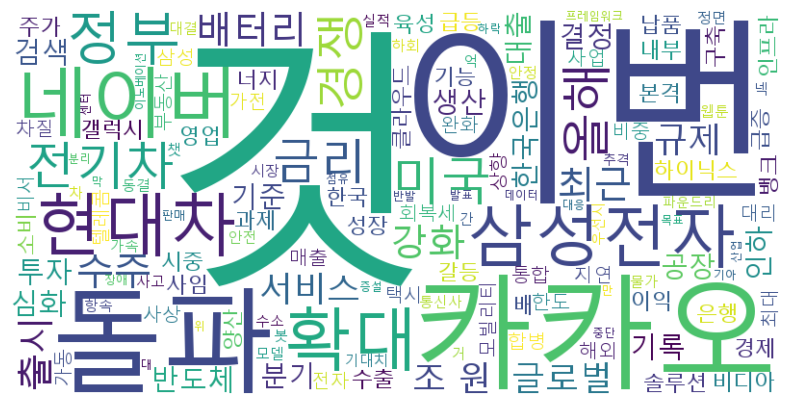

In [6]:
# 📌 §310 Pecab nouns
# ✍️ Pecab 명사 추출 후 워드클라우드를 생성해보세요
# (힌트: PeCab() → for문으로 pecab.nouns(title) → extend → " ".join → WordCloud)
# 코드를 작성해주세요 👇
# Pecab 명사 추출 → 워드클라우드
from pecab import PeCab

pecab = PeCab()

# 전체 뉴스 제목에서 명사만 추출
all_nouns = []
for title in titles:
    all_nouns.extend(pecab.nouns(title))

# 명사를 공백으로 연결 → WordCloud에 전달
nouns_text = " ".join(all_nouns)

wc_nouns = WordCloud(
    font_path=FONT_PATH,
    width=800, height=400,
    background_color="white",
    random_state=42,
).generate(nouns_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_nouns, interpolation="bilinear")
plt.axis("off")
plt.show()


# 예상 출력: 명사만 남은 깔끔한 워드클라우드 — "삼성전자", "AI", "경쟁" 등이 크게 나옴

'AI' 포함 제목 수: 8


c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kik32\workspace\unstructured-data-processi

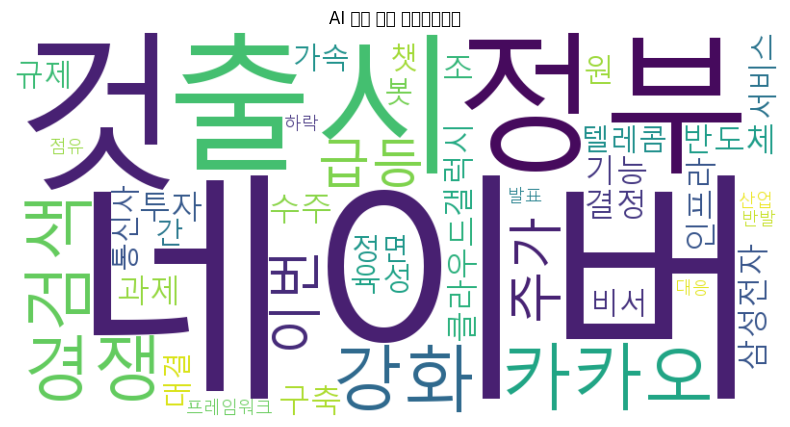

In [7]:
# 📌 §310 Keyword filter
# ✍️ "AI" 포함 제목만 필터링한 뒤 Pecab nouns 워드클라우드를 생성해보세요
# (힌트: [t for t in titles if "AI" in t] → 명사 추출 → WordCloud)
# 코드를 작성해주세요 👇
# "AI" 포함 제목만 필터링
keyword = "AI"
titles_ai = [t for t in titles if keyword in t]
print(f"'{keyword}' 포함 제목 수: {len(titles_ai)}")
# 'AI' 포함 제목 수: 8

# 필터링된 제목에서 명사 추출
ai_nouns = []
for title in titles_ai:
    ai_nouns.extend(pecab.nouns(title))

ai_nouns_text = " ".join(ai_nouns)

wc_ai = WordCloud(
    font_path=FONT_PATH,
    width=800, height=400,
    background_color="white",
    random_state=42,
).generate(ai_nouns_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ai, interpolation="bilinear")
plt.axis("off")
plt.title("AI 관련 기사 워드클라우드")
plt.show()


# 예상 출력: 'AI' 포함 제목 수: 8 + AI 관련 키워드 워드클라우드